In [1]:
%load_ext autoreload
%autoreload 2


## Data

### Ru Freq

In [68]:
import pandas as pd

ru_freq_data = pd.read_csv("data/freqrnc2011.csv", sep='\t')

ru_freq_data.head()


,Lemma,PoS,Freq(ipm),R,D,Doc
0,а,conj,8198.0,100,97,32332
1,а,intj,19.8,99,90,757
2,а,part,6.1,59,79,128
3,а,s,2.7,59,85,160
4,аа,intj,1.5,47,80,68


In [69]:
ru_freq_data = ru_freq_data[ru_freq_data['Lemma'].str.isalpha()]

In [70]:
ru_freq_data['Lang'] = "RU"

In [71]:
cefr = pd.qcut(ru_freq_data["Freq(ipm)"], [.0, .1, .25, .5, .75, .9, 1], ["C2", "C1", "B2", "B1", "A2", "A1"])


In [72]:
ru_freq_data["Level"] = cefr


In [73]:
ru_freq_data[ru_freq_data['Lemma'].str.contains('-')]


,Lemma,PoS,Freq(ipm),R,D,Doc,Lang,Level


In [74]:
ru_freq_data[cefr=="C2"]


,Lemma,PoS,Freq(ipm),R,D,Doc,Lang,Level
19,абонементный,a,0.4,24,76,30,RU,C2
22,абордаж,s,0.5,38,85,44,RU,C2
37,абсолютизировать,v,0.5,30,78,41,RU,C2
40,абсолютность,s,0.4,28,82,35,RU,C2
42,абсорбент,s,0.4,6,34,7,RU,C2
...,...,...,...,...,...,...,...,...
52111,ясновидящая,s,0.5,25,72,31,RU,C2
52118,ястребиный,a,0.4,21,76,33,RU,C2
52123,яхтсмен,s,0.5,19,72,22,RU,C2
52134,ящерка,s,0.4,27,82,33,RU,C2


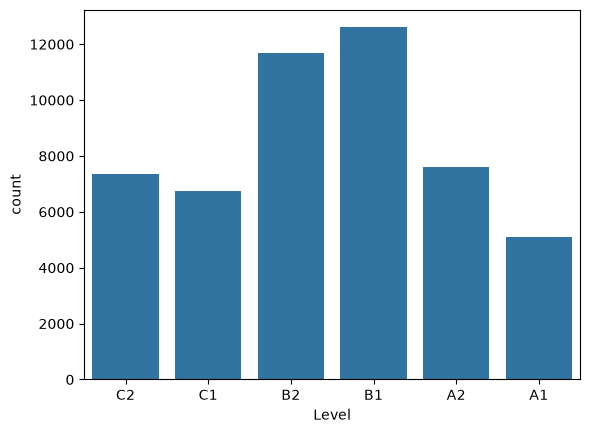

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.countplot(ru_freq_data, x="Level")
plt.show()


### Eng Freq

In [11]:
import pandas as pd

eng_freq_data = pd.read_csv("data/I159729.csv")

eng_freq_data.head()


FileNotFoundError: [Errno 2] No such file or directory: 'data/I159729.csv'

In [44]:
eng_freq_data = eng_freq_data.rename(columns={"Word": "Lemma"})
eng_freq_data["Lang"] = "ENG"


In [45]:
eng_freq_data = eng_freq_data[eng_freq_data["Freq_HAL"] != 0]
eng_freq_data = eng_freq_data[eng_freq_data["Lemma"].str.isalpha()]


In [46]:
eng_freq_data[eng_freq_data['Lemma'].str.contains("\\d", regex=True)]


,Lemma,Length,Freq_HAL,Log_Freq_HAL,I_Mean_RT,I_Zscore,I_SD,Obs,I_Mean_Accuracy,Lang


In [47]:
cefr = pd.qcut(eng_freq_data["Freq_HAL"], [.0, .25, .5, .75, .9, .95, 1], ["C2", "C1", "B2", "B1", "A2", "A1"])


In [48]:
eng_freq_data["Level"] = cefr


In [49]:
eng_freq_data[eng_freq_data["Level"] == "C2"]


,Lemma,Length,Freq_HAL,Log_Freq_HAL,I_Mean_RT,I_Zscore,I_SD,Obs,I_Mean_Accuracy,Lang,Level
9,abase,5,30,3.40,803.27,0.03,309.52,22.0,0.69,ENG,C2
10,abasement,9,7,1.95,1037.06,0.92,311.84,17.0,0.53,ENG,C2
11,abash,5,1,0.00,748.71,0.23,194.37,21.0,0.68,ENG,C2
14,abbess,6,33,3.50,885.14,0.28,324.20,7.0,0.22,ENG,C2
21,abdicate,8,118,4.77,1056.00,0.84,475.66,18.0,0.56,ENG,C2
...,...,...,...,...,...,...,...,...,...,...,...
40440,zealotry,8,62,4.13,1077.86,0.90,735.27,7.0,0.23,ENG,C2
40444,zeitgeist,9,111,4.71,1129.75,1.15,338.49,4.0,0.13,ENG,C2
40453,zigzag,6,110,4.70,785.26,-0.07,254.95,34.0,1.00,ENG,C2
40454,zigzagging,10,16,2.77,955.40,0.32,383.98,25.0,0.78,ENG,C2


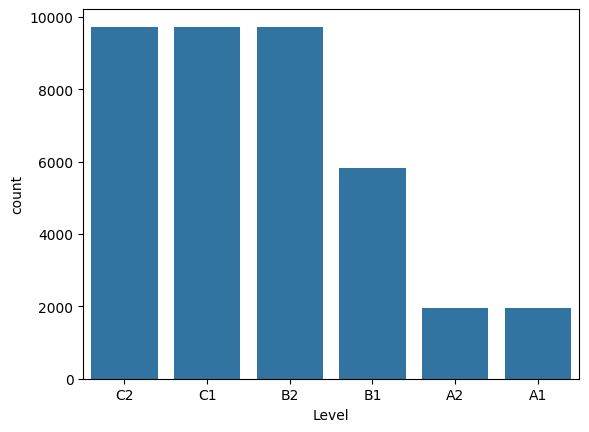

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.countplot(eng_freq_data, x="Level")
plt.show()


### Ru CEFR

### Eng CEFR

## Dataset

In [47]:
data = ru_freq_data

In [10]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.3, stratify=data['Level'])


In [48]:
from tokenizer import get_bpe_tokenizer, get_char_tokenizer, ENGALPHAPBET

MAX_LEN = 16

# tokenizer = get_char_tokenizer(ENGALPHAPBET, MAX_LEN)
tokenizer = get_bpe_tokenizer(train['Lemma'])


In [49]:
PAD_IDX = tokenizer.pad_token_id
BOS_IDX = tokenizer.bos_token_id
EOS_IDX = tokenizer.eos_token_id
UNK_IDX = tokenizer.unk_token_id


In [51]:
from dataset import LLLDataset, LEVELS, LANGUAGES, NUM_LEVELS, NUM_LANGS

dataset = LLLDataset(data[["Lemma", "Level", "Lang"]], tokenizer, max_len=MAX_LEN)


In [52]:
train_set = LLLDataset(train[["Lemma", "Level", "Lang"]], tokenizer, max_len=MAX_LEN)
test_set = LLLDataset(test[["Lemma", "Level", "Lang"]], tokenizer, max_len=MAX_LEN)


In [15]:
from torch.utils.data import Subset
import numpy as np

small_set = Subset(train_set, np.random.choice(np.arange(len(train_set)), size=32, replace=False))


In [53]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=16, drop_last=False, shuffle=False)
small_loader = DataLoader(small_set, batch_size=4, drop_last=True, shuffle=True)


## Utils

In [76]:
import torch

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'


print(f'using {device} device')


using mps device


In [77]:
import os.path

BASE_PATH = './checkpoints/'
get_path = lambda model_name: os.path.join(BASE_PATH, model_name)


In [78]:
import torch.nn as nn

def get_model_device(model: nn.Module):
    return next(model.parameters()).device


## Train

In [79]:
MODEL_NAME = "TestModel"

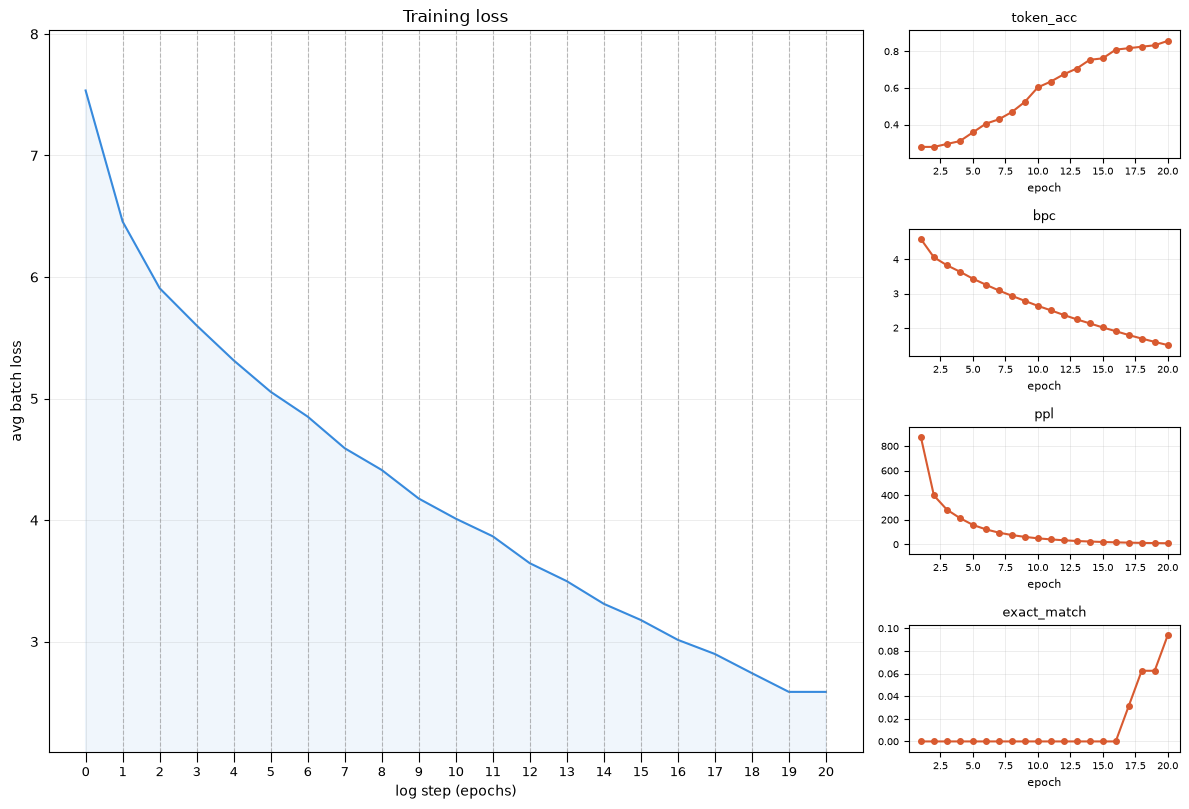

In [80]:
import torch.optim as optim
from model import LLTransformer
from utils.logger import PlotLogger, TQDMLogger
from utils.checkpointer import CheckPointer
from utils.trainer import LLTrainer
from utils.func import n_params
from utils.metrics import TokenCrossEntropyLoss, TokenAccuracy, BitsPerChar, Perplexity, SequenceExactMatch


vocab_size = len(tokenizer.get_vocab()) + len(tokenizer.get_added_vocab())
model = LLTransformer(
    vocab_size=vocab_size,
    d_model=256,
    nhead=4,
    num_layers=3,
    dim_feedforward=1024,
    num_levels=NUM_LEVELS,
    max_positions=MAX_LEN,
    pad_idx=PAD_IDX,
    dropout=0.2,
).to(device)

print(f"Trainable params: {n_params(model):,}")

chkpter = CheckPointer(model, get_path(MODEL_NAME))
logger = PlotLogger(log_every_n_step=100)
trainer = LLTrainer(model, logger, device, chkpter)

train_params = {
    'criterion': TokenCrossEntropyLoss(ignore_index=PAD_IDX),
    'opt': optim.AdamW(model.parameters(), lr=1e-4)
}

val_params = {
    'metrics': {
          'token_acc': TokenAccuracy(vocab_size, PAD_IDX),
          'bpc': BitsPerChar(tokenizer, PAD_IDX),
          'ppl': Perplexity(PAD_IDX),
          'exact_match': SequenceExactMatch(PAD_IDX, EOS_IDX),
      }
}

model = trainer.fit(small_loader, train_params, small_loader, val_params, epochs=20)


In [81]:
tokenizer.save_pretrained(get_path(MODEL_NAME))


('./checkpoints/TestModel/tokenizer_config.json',
 './checkpoints/TestModel/tokenizer.json')

In [82]:
trainer.logger.save(trainer.chkpter.chkpt_path)


## Eval

In [83]:
from torch.nn.functional import softmax
import torch
from dataset import level2idx, lang2idx


@torch.no_grad()
def generate_word(model, level, lang, tokenizer, device, max_len=32, temperature=0.8, do_sample=True):
    model.eval()

    level_idx = torch.tensor([level2idx[level]], device=device)

    generated = [BOS_IDX]

    # with torch.no_grad():
    for _ in range(max_len):
        input_ids = torch.tensor([generated], device=device)
        attention_mask = torch.ones_like(input_ids, device=device)

        logits = model(input_ids, level_idx, attention_mask)
        next_token_logits = logits[0, -1, :] / temperature


        if do_sample:
            probs = softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()
        else:
            next_token = torch.argmax(next_token_logits).item()
        if next_token == EOS_IDX:
            break

        generated.append(next_token)

    decoded = tokenizer.decode(generated[1:], skip_special_tokens=True)

    word = decoded.strip().replace(' ', '')
    return word


In [84]:
generate_word(model, "C2", "RU", tokenizer, device, max_len=MAX_LEN, do_sample=True, temperature=.8)


'рорат'

## Complexity Classifier

Char-level transformer that predicts CEFR level (A1–C2) for any word, including non-dictionary ones generated by the LM. Trained on the same `(lemma, level)` pairs used for the LM.

In [85]:
from utils.complexity_clf import ComplexityDataset

clf_train_set = ComplexityDataset(train[["Lemma", "Level"]], tokenizer, max_len=MAX_LEN)
clf_test_set = ComplexityDataset(test[["Lemma", "Level"]], tokenizer, max_len=MAX_LEN)

clf_train_loader = DataLoader(clf_train_set, batch_size=64, drop_last=True, shuffle=True)
clf_test_loader = DataLoader(clf_test_set, batch_size=64, drop_last=False, shuffle=False)

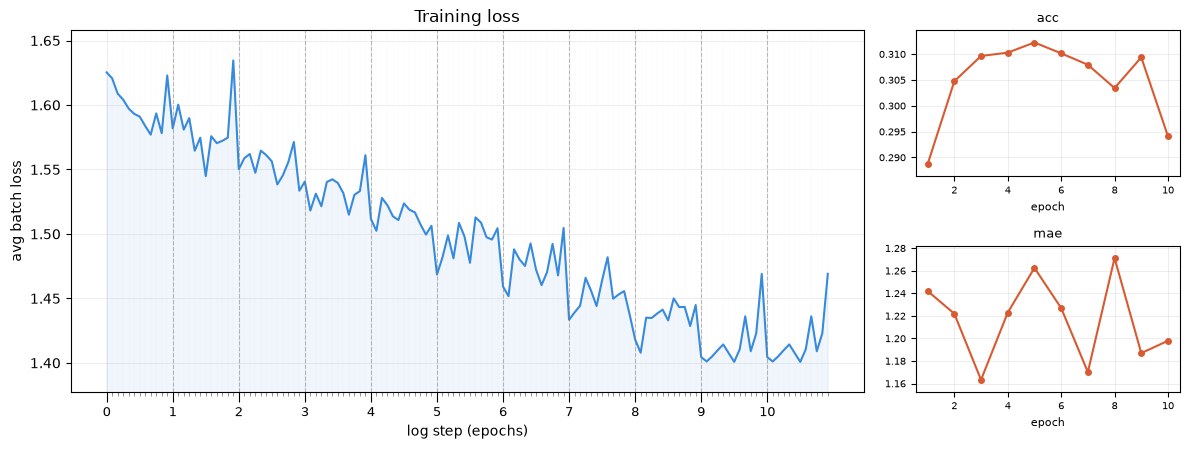

In [86]:
from utils.complexity_clf import WordComplexityClassifier
from utils.trainer import ClassifierTrainer
from utils.metrics import ClassificationAccuracy, OrdinalMAE

CLF_NAME = "ComplexityClf"

clf = WordComplexityClassifier(
    vocab_size=vocab_size,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=512,
    num_levels=NUM_LEVELS,
    max_positions=MAX_LEN,
    pad_idx=PAD_IDX,
    dropout=0.2,
).to(device)

print(f"Trainable params: {n_params(clf):,}")

clf_chkpter = CheckPointer(clf, get_path(CLF_NAME))
clf_logger = PlotLogger(log_every_n_step=50)
clf_trainer = ClassifierTrainer(clf, clf_logger, device, clf_chkpter)

clf_train_params = {
    'criterion': nn.CrossEntropyLoss(),
    'opt': optim.AdamW(clf.parameters(), lr=3e-4),
}

clf_val_params = {
    'metrics': {
        'acc': ClassificationAccuracy(NUM_LEVELS),
        'mae': OrdinalMAE(),
    },
}

clf = clf_trainer.fit(clf_train_loader, clf_train_params, clf_test_loader, clf_val_params, epochs=10)

In [87]:
clf_test_scores = clf_trainer.test(clf_test_loader, clf_val_params['metrics'])
clf_test_scores

{'acc': 0.294106125831604, 'mae': 1.1979635953903198}

In [88]:
from utils.complexity_clf import predict_levels, predict_proba

# Mix of real (varying difficulty) and made-up words
sample_words = ["мама", "дом", "кот", "аберрация", "ятаган", "квазимодальный", "глокая", "куздра"]
predicted = predict_levels(clf, sample_words, tokenizer, device, max_len=MAX_LEN)
list(zip(sample_words, predicted))

[('мама', 'A1'),
 ('дом', 'A1'),
 ('кот', 'B1'),
 ('аберрация', 'C2'),
 ('ятаган', 'C1'),
 ('квазимодальный', 'B2'),
 ('глокая', 'C1'),
 ('куздра', 'B1')]

In [89]:
# Probe LM ↔ classifier consistency: generate N words at each target level, then have the classifier predict their level.
from utils.generation import generate_batch
import numpy as np

N_PER_LEVEL = 64
# Only pass lang when the LM actually conditions on it (LLLTransformer); LLTransformer would error.
lang_arg = "RU" if hasattr(model, "lang_embedding") else None

confusion = {}
for target in LEVELS:
    words = generate_batch(model, tokenizer, N_PER_LEVEL,
                           level=target, lang=lang_arg,
                           max_len=MAX_LEN, temperature=0.8, do_sample=True)
    preds = predict_levels(clf, words, tokenizer, device, max_len=MAX_LEN)
    confusion[target] = {lvl: preds.count(lvl) / N_PER_LEVEL for lvl in LEVELS}

pd.DataFrame(confusion).T[LEVELS]  # rows = target, cols = predicted

,A1,A2,B1,B2,C1,C2
A1,0.437500,0.015625,0.203125,0.218750,0.093750,0.031250
A2,0.125000,0.000000,0.109375,0.265625,0.250000,0.250000
B1,0.203125,0.015625,0.234375,0.296875,0.125000,0.125000
B2,0.125000,0.000000,0.203125,0.234375,0.234375,0.203125
C1,0.125000,0.015625,0.250000,0.421875,0.125000,0.062500
C2,0.078125,0.000000,0.218750,0.203125,0.328125,0.171875
